COE FINAL PART 2

zachary matthews zrm494

alan ji ayj333

# Section 1

We chose to model the stiff system of cooling with forced convection. 

The governing ODE would be:
 
dT/dt = -h(T - T_∞(t))

h - convection coefficient (1/seconds)
T - temperature (kelvin) 
t - time (seconds)
T_∞(t) - ambient temperature at time t (kelvin)

This system is important in practice, as it models the temperature of an object that is forcibly being cooled, which can be used in many applications, from radiators to reactors.

We are using a convection coefficient of -1000, and an ambient temperature function of 300 + 50sin(0.01t)

dT/dt = -1000T + 1000(300 + 50sin(0.01t))

# Section 2

<ipython-input-66-0de17b7f7257>:3: RuntimeWarning: overflow encountered in double_scalars
  return (-1000 * T + 1000*(300 + 50*np.sin(0.01*t)))
<ipython-input-66-0de17b7f7257>:22: RuntimeWarning: invalid value encountered in double_scalars
  T_values[i + 1] = T_values[i] + h * f(t_values[i], T_values[i])


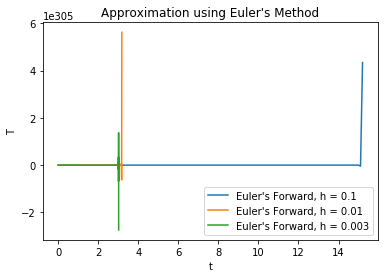

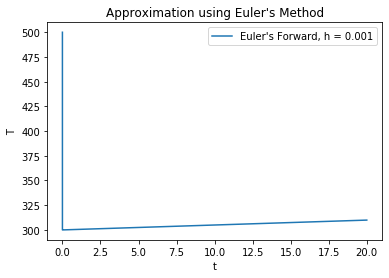

In [66]:
# Function representing diff eq
def f(t, T):
    return (-1000 * T + 1000*(300 + 50*np.sin(0.01*t)))

T_init = 500 #initial condition in Kelvin
t_init = 0 #initial condition of 0 seconds
t_final = 20 #end at 20 seconds

import numpy as np
import matplotlib.pyplot as plt

# Define parameters
def forward_euler(T0, t0, tf, h):
    num_steps = int((tf - t0) / h)
    t_values = np.linspace(t0, tf, num_steps + 1)
    T_values = np.zeros(num_steps + 1)
    # Initial condition
    T_values[0] = T0 # y(0) = 1
    # Implement Euler's method

    for i in range(0, num_steps):
        T_values[i + 1] = T_values[i] + h * f(t_values[i], T_values[i])
    return t_values, T_values
# Plot the results

h_list = np.array([0.1, 0.01, 0.003])
for h in h_list:
    forward_t_values, forward_T_values = forward_euler(T_init, t_init, t_final, h)
    plt.plot(forward_t_values, forward_T_values, label="Euler's Forward, h = " + str(h))
plt.xlabel('t')
plt.ylabel('T')
plt.title("Approximation using Euler's Method")
plt.legend()
plt.show()

forward_t_values, forward_T_values = forward_euler(T_init, t_init, t_final, 0.001)
plt.plot(forward_t_values, forward_T_values, label="Euler's Forward, h = 0.001")
plt.xlabel('t')
plt.ylabel('T')
plt.title("Approximation using Euler's Method")
plt.legend()
plt.show()


# Section 3

T(n+1) = T(n) + hf(t(n+1), T(n+1))

R(T(n+1)) = T(n+1) - T(n) - hf(t(n+1), T(n+1))

R(T(n+1)) = T(n+1) - T(n) - h(-1000T(n+1) + 1000(300 + 50sin(0.01t(n+1)))

Final Residual Function: R(T(n+1)) = (1 + 1000h)*T(n+1) - T(n) - 1000h(300 + 50sin(0.01*t(n+1)))

Analytical Derivative of Residual: R'(T(n+1)) = dR/dT(n+1) = 1 + 1000h

T(k+1) = T(k) - R(k+1)/R'(k+1)

Final Newton-Raphson update equation:

T(n+1) = (T(n) + 1000*h(300+50sin(0.01t(n+1))))/(1+1000h)

# Section 4

In [124]:
# Function representing diff eq
def f(t, T):
    return (-1000 * T + 1000*(300 + 50*np.sin(0.01*t)))

# Derivative of residual (constant!)
def dR_dT(h):
    return 1 + 1000*h

def residual(T_new, T_old, t_new, h):
    return T_new - T_old - h * f(t_new, T_new)

# Newton-Raphson solver
def newton_solver(T_guess, T_old, t_new, h, tol=1e-8, max_iter=10):
    T = T_guess
    it_counter = 0 #used to check number of iterations
    for _ in range(max_iter):
        R = residual(T, T_old, t_new, h)
        dR = dR_dT(h)
        T_new = T - R / dR
        it_counter += 1 
        if abs(T_new - T) < tol:
            return T_new, it_counter
        
        T = T_new
    return T, it_counter  # fallback

# Backward Euler
def backward_euler(T0, t0, tf, h):
    t_vals = np.arange(t0, tf + h, h)
    T_vals = np.zeros(len(t_vals))
    
    T_vals[0] = T0
    total_iterations = 0
    newton_calls = 0
    for i in range(len(t_vals) - 1):
        t_new = t_vals[i+1]
        
        # initial guess = previous value
        T_guess = T_vals[i]
        
        T_vals[i+1], iterations = newton_solver(T_guess, T_vals[i], t_new, h) #use Newton-Raphson method for implicit calculation
        newton_calls += 1
        total_iterations += iterations
    return t_vals, T_vals, (total_iterations/newton_calls)

def analytical(t):
    return (300+(50000.0*(1000.0*np.sin(0.01*t) - 0.01*np.cos(0.01*t)))/(1000000.0 + 0.0001) + 200.0*np.exp(-1000.0*t))

# Section 5

Average Newton iterations for h =  0.001 :  2.0
Average Newton iterations for h =  0.01 :  2.0
Average Newton iterations for h =  0.1 :  2.0
Average Newton iterations for h =  1.0 :  2.0
Average Newton iterations for h =  2.0 :  2.0
Average Newton iterations for h =  20.0 :  2.0


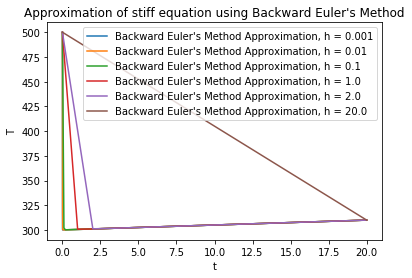

In [125]:
backwards_h_list = np.array([0.001, 0.01, 0.1, 1, 2, 20])
for h in backwards_h_list:
    backwards_t_values, backwards_T_values, avg_its = backward_euler(T_init, t_init, t_final, h)
    plt.plot(backwards_t_values, backwards_T_values, label="Backward Euler's Method Approximation, h = " + str(h))
    print("Average Newton iterations for h = ", h, ": ", avg_its)
plt.xlabel('t')
plt.ylabel('T')
plt.title("Approximation of stiff equation using Backward Euler's Method")
plt.legend()
plt.show()

There is very little difference in average Newton-Raphson Method iterations for different step sizes. This is likely due to its linearity, which consistently gets a good guess in only one iterations. The extreme tolerance and floating point errors are likely the only reason it even needs the second iteration.

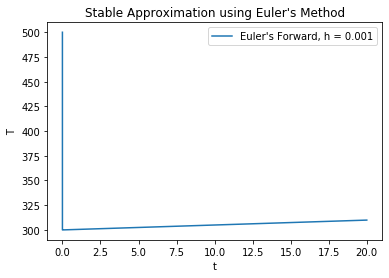

<ipython-input-124-68eb9d3bf1be>:3: RuntimeWarning: overflow encountered in double_scalars
  return (-1000 * T + 1000*(300 + 50*np.sin(0.01*t)))
<ipython-input-66-0de17b7f7257>:22: RuntimeWarning: invalid value encountered in double_scalars
  T_values[i + 1] = T_values[i] + h * f(t_values[i], T_values[i])


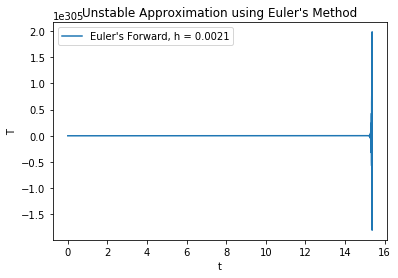

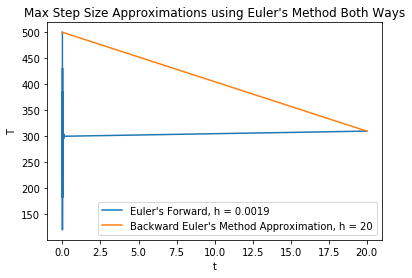

In [126]:
forward_t_values, forward_T_values = forward_euler(T_init, t_init, t_final, 0.001)
plt.plot(forward_t_values, forward_T_values, label="Euler's Forward, h = 0.001")
plt.xlabel('t')
plt.ylabel('T')
plt.title("Stable Approximation using Euler's Method")
plt.legend()
plt.show()

forward_t_values, forward_T_values = forward_euler(T_init, t_init, t_final, 0.0021)
plt.plot(forward_t_values, forward_T_values, label="Euler's Forward, h = 0.0021")
plt.xlabel('t')
plt.ylabel('T')
plt.title("Unstable Approximation using Euler's Method")
plt.legend()
plt.show()

forward_t_values, forward_T_values = forward_euler(T_init, t_init, t_final, 0.0019)
plt.plot(forward_t_values, forward_T_values, label="Euler's Forward, h = 0.0019")
backwards_t_values, backwards_T_values, avg_its = backward_euler(T_init, t_init, t_final, 20)
plt.plot(backwards_t_values, backwards_T_values, label="Backward Euler's Method Approximation, h = 20")
plt.xlabel('t')
plt.ylabel('T')
plt.title("Max Step Size Approximations using Euler's Method Both Ways")
plt.legend()
plt.show()

Forward Average Error =  0.005819501342763338
Backward Average Error =  0.004180074176717769


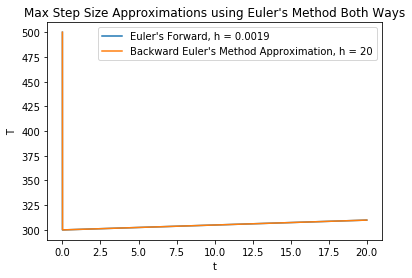

In [131]:
forward_t_values, forward_T_values = forward_euler(T_init, t_init, t_final, 0.001)
plt.plot(forward_t_values, forward_T_values, label="Euler's Forward, h = 0.0019")
forward_total_error = 0
for i in range(0, len(forward_T_values)):
    forward_total_error += np.abs(forward_T_values[i] - analytical(forward_t_values[i]))
print("Forward Average Error = ", forward_total_error/(len(forward_t_values)))
backwards_t_values, backwards_T_values, avg_its = backward_euler(T_init, t_init, t_final, 0.001)
plt.plot(backwards_t_values, backwards_T_values, label="Backward Euler's Method Approximation, h = 20")
backward_total_error = 0
for i in range(0, len(backwards_T_values)):
    backward_total_error += np.abs(backwards_T_values[i] - analytical(backwards_t_values[i]))
print("Backward Average Error = ", backward_total_error/(len(backwards_t_values)))
plt.xlabel('t')
plt.ylabel('T')
plt.title("Max Step Size Approximations using Euler's Method Both Ways")
plt.legend()
plt.show()

The Backwards Euler method still gets a lower average error than Forwards Euler even at step sizes where Forwards Euler is stable.

| Method | Stable Range |
|------------|-------------------------|
| Forward Euler	 | h < 0.002|
| Backward Euler | h > 0|



The Newton Raphson method on this stiff equation theoretically converges in one iteration because the residual is linear (as in it has the form a*(T(n+1)) + b). This means the method is fairly efficient, which is good because Backward Euler is a higher cost method.

However, in practice, it takes 2 iterations each time! This is due to floating point errors combined with the fairly intense tolerance criteria.

# Section 6

In general, Euler’s Backward method is more computationally expensive. 

| Method | Computation Cost | Stability Characteristics |
|------------|-------------------------|---------------------------------|
| Forward Euler	 | Lower cost due to explicit updates.	| Less stable, especially for stiff equations. |
| Backward Euler | Higher cost because it requires solving an implicit equation at each step. | More stable, suitable for stiff equations. |

However, the tradeoff is that Backwards Euler is more accurate, which in practice reduces the computational cost, as larger step sizes can be used while maintaining stability, compared to Euler’s forwards.
Practically, this means that Euler’s Backward method is the recommended method, as the computational cost is offset by the lessened requirement of step size, while also being more accurate than Forward Euler.


# Section 7

We found that the implicit method performed better than the explicit one for larger time steps. Thus, we should use explicit methods for problems where stability is not a concern and smaller time steps are acceptable, while implicit methods are preferred for stiff problems that require larger time steps and greater stability. We faced challenges getting  Euler’s Forwards to function correctly, as the instability inherent to the methods led to nonsensical graphs. We learned quickly why Euler’s Backwards method is preferable for stiff equations.